# 1. Import Libraries

In [2]:
!pip install transformers scikit-learn datasets 'accelerate>=1.1.0'
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


/home/lenovo/Documents/School/Sem6/PBA/pba-task-group/.env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Load Model

In [3]:
model_name = "w11wo/indonesian-roberta-base-sentiment-classifier"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6636.09it/s]


# 3. Prepare Dataset

In [4]:
df = pd.read_csv("../outputs/dataset_preprocessed_bert.csv")

labels_map = {
    "Positive": 2,
    "Neutral": 1,
    "Negative": 0
}

labels = ["Negative", "Positive", "Neutral"]


df["manual_sentiment_mapped"] = df["manual sentiment"].map(labels_map)
df

,url,judul,konten,manual sentiment,konten_length,konten_preprocessed,manual_sentiment_mapped
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8328,jakarta cnbc indonesia amerika serikat as seca...,2
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,jakarta cnbc indonesia nilai tukar rupiah terh...,2
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,jakarta cnbc indonesia pasar keuangan indonesi...,2
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,5158,jakarta cnbc indonesia indeks harga saham gabu...,0
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,4767,hargabitcoin btc pernah melewati angka terting...,2
...,...,...,...,...,...,...,...
994,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,Positive,3756,jakarta tiga produsen mesin penambang bitcoin ...,2
995,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,Neutral,3319,presiden amerika serikat as donald trump menga...,1
996,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",Negative,4713,bisnis com jakarta serangan amerika serikat as...,0
997,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",Negative,2830,jakarta cnbc indonesia perusahaan semikondukto...,0


# 4. Tokenise Data

In [5]:
encodings = tokenizer(
    df["konten"].tolist(),
    truncation=True,
    padding="max_length",
    max_length=128
)

df["input_ids"] = encodings["input_ids"]
df["attention_mask"] = encodings["attention_mask"]

X = df.drop(columns=["manual_sentiment_mapped"])
y = df["manual_sentiment_mapped"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_df = X_train.copy()
train_df["manual_sentiment_mapped"] = y_train

test_df = X_test.copy()
test_df["manual_sentiment_mapped"] = y_test

train_df

,url,judul,konten,manual sentiment,konten_length,konten_preprocessed,input_ids,attention_mask,manual_sentiment_mapped
859,https://www.cnbcindonesia.com/opini/2025051915...,TKDN Fleksibel Bukan Strategi Atasi Tarif Daga...,Catatan:Artikel ini merupakan opini pribadi pe...,Neutral,7746,catatan artikel ini merupakan opini pribadi pe...,"[0, 15506, 30, 16587, 330, 767, 11128, 2115, 2...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1
588,https://www.metrotvnews.com/read/NOlCAYgw-bisn...,"Bisnis Mandek, UMKM di AS Gugat Trump - MetroT...",New York: Sejumlah pelaku usaha mikro kecil da...,Negative,1246,new york sejumlah pelaku usaha mikro kecil dan...,"[0, 23934, 10159, 30, 13884, 3465, 1474, 7914,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
296,https://www.cnbcindonesia.com/research/2025040...,Lengkap! Ini Daftar Tarif Dagang Trump ke Semu...,"Jakarta, CNBC Indonesia- Presiden Amerika seri...",Neutral,2504,jakarta cnbc indonesia presiden amerika serika...,"[0, 6758, 16, 35210, 7778, 622, 17, 2982, 2502...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1
59,https://www.metrotvnews.com/read/b7WCg6wM-kila...,Kilas Balik Perang Dagang Pertama Trump dan Ke...,Washington DC:Donald Trumpmemulai perang dagan...,Negative,849,washington dc donald trumpmemulai perang dagan...,"[0, 59, 3742, 15409, 15424, 30, 40, 15799, 111...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
172,https://www.cnbcindonesia.com/news/20250304060...,"Trump ""Gebuk"" Xi Jinping Lagi, Resmi AS Tambah...","Jakarta, CNBC Indonesia- Serangan baru diberik...",Negative,2365,jakarta cnbc indonesia serangan baru diberikan...,"[0, 6758, 16, 35210, 7778, 622, 17, 24805, 729...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
...,...,...,...,...,...,...,...,...,...
235,https://money.kompas.com/read/2025/03/24/09153...,Siapa Menanggung Efek Perang Dagang Trump? - K...,TARIFmenjadi salah satu kebijakan kontroversia...,Neutral,10861,tarifmenjadi salah satu kebijakan kontroversia...,"[0, 48177, 8382, 23587, 649, 519, 3057, 21591,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1
753,https://www.cnnindonesia.com/internasional/202...,"PM Kanada: Trump Khianati Kita, Relasi Lama de...","Perdana MenteriKanadayang baru, Mark Carney, m...",Negative,2922,perdana menterikanadayang baru mark carney men...,"[0, 1523, 28614, 4755, 15693, 325, 1609, 729, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
736,https://sulteng.antaranews.com/berita/346169/1...,"100 hari Trump 2.0: Catur 4D, poker politik, d...",Jakarta (ANTARA) - Sejumlah pendukung Presiden...,Neutral,9002,jakarta antara sejumlah pendukung presiden as ...,"[0, 6758, 423, 30546, 13, 824, 13884, 4533, 29...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1
496,https://www.kompas.id/artikel/tidak-jadi-mesra...,"Tidak Jadi Mesra, Kripto Malah Jatuh Ketika Tr...",Para pelaku bisnis aset kripto yakin kalau Don...,Negative,15285,para pelaku bisnis aset kripto yakin kalau don...,"[0, 5790, 3465, 1252, 5559, 24882, 2732, 1021,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0


# 5. Convert to Torch

In [6]:
#train dataset
input_ids = torch.tensor(train_df["input_ids"].tolist())
attention_mask = torch.tensor(train_df["attention_mask"].tolist())
labels = torch.tensor(train_df["manual_sentiment_mapped"].values).long()

train_dataset = [
    {
        "input_ids": input_ids[i],
        "attention_mask": attention_mask[i],
        "labels": labels[i]
    }
    for i in range(len(train_df))
]

#test dataset
input_ids_2 = torch.tensor(test_df["input_ids"].tolist())
attention_mask_2 = torch.tensor(test_df["attention_mask"].tolist())
labels_2 = torch.tensor(test_df["manual_sentiment_mapped"].values).long()

test_dataset = [
    {
        "input_ids": input_ids_2[i],
        "attention_mask": attention_mask_2[i],
        "labels": labels_2[i]
    }
    for i in range(len(test_df))
]

# 6. Train Model

In [7]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    logging_steps=10
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()

Step,Training Loss
10,1.266991
20,1.120748
30,1.040085
40,1.059885
50,1.041826
60,1.079622
70,1.026196
80,1.187588
90,1.068797
100,0.938272


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.30s/it]


TrainOutput(global_step=300, training_loss=0.9257785336176554, metrics={'train_runtime': 82.8185, 'train_samples_per_second': 28.943, 'train_steps_per_second': 3.622, 'total_flos': 157670715573504.0, 'train_loss': 0.9257785336176554, 'epoch': 3.0})

## 6.1 Evaluate

In [8]:
trainer.evaluate()

Training Loss,Validation Loss,Step
0.629836,0.945457,300


{'eval_loss': 0.9454565644264221}

# 7. Predict

In [9]:
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(axis=1)
trues = predictions.label_ids

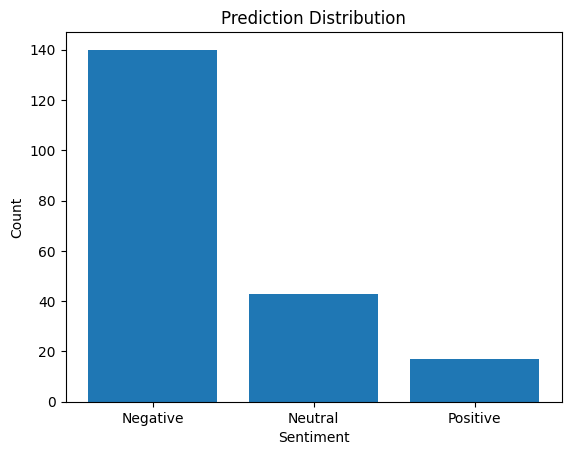

In [10]:
counts = {0: 0, 1: 0, 2: 0}

for p in preds:
    counts[p] += 1

neg = counts[0]
net = counts[1]
pos = counts[2]

import matplotlib.pyplot as plt

labels = ["Negative", "Neutral", "Positive"]
values = [neg, net, pos]

plt.bar(labels, values)

plt.title("Prediction Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# 8. Evaluate Performance

In [11]:
preds_labeled = [labels[x] for x in preds]
trues_labeled = [labels[x] for x in trues]

print(preds_labeled)
print(trues_labeled)

['Negative', 'Negative', 'Negative', 'Negative', 'Neutral', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Neutral', 'Neutral', 'Neutral', 'Negative', 'Neutral', 'Negative', 'Negative', 'Negative', 'Negative', 'Positive', 'Negative', 'Negative', 'Negative', 'Positive', 'Neutral', 'Negative', 'Positive', 'Neutral', 'Negative', 'Neutral', 'Positive', 'Neutral', 'Negative', 'Negative', 'Negative', 'Positive', 'Negative', 'Neutral', 'Neutral', 'Negative', 'Negative', 'Negative', 'Neutral', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Positive', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Neutral', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Neutral', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Neutral', 'Neutral', 'Neutral', 'Negative', 'Neutral', 'Negative', 'Negative', 'Negative

## 8.1 Confusion Matrix

In [12]:
cm = confusion_matrix(trues, preds)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print(cm_df)

          Negative  Neutral  Positive
Negative        92       12         5
Neutral         33       14         5
Positive        15       17         7


## 8.2 Accuracy

In [13]:
correct = 0

for i in range(len(preds)):
    if preds[i] == trues[i]:
        correct += 1

accuracy = correct / len(preds)

print("Accuracy:", accuracy)

Accuracy: 0.565


## 8.3 Precision, Recall

In [14]:
results = {}

for cls in labels:
    tp = 0
    fp = 0
    fn = 0

    for i in range(len(trues_labeled)):
        if preds_labeled[i] == cls and trues_labeled[i] == cls:
            tp += 1
        elif preds_labeled[i] == cls and trues_labeled[i] != cls:
            fp += 1
        elif preds_labeled[i] != cls and trues_labeled[i] == cls:
            fn += 1

    # avoid division by zero
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    results[cls] = {
        "precision": precision,
        "recall": recall
    }

for k in results.keys():
    print(k, ":", results[k])

Negative : {'precision': 0.6571428571428571, 'recall': 0.8440366972477065}
Neutral : {'precision': 0.32558139534883723, 'recall': 0.2692307692307692}
Positive : {'precision': 0.4117647058823529, 'recall': 0.1794871794871795}


# Citations

@misc {wilson_wongso_2023,
    author       = { {Wilson Wongso} },
    title        = { indonesian-roberta-base-sentiment-classifier (Revision e402e46) },
    year         = 2023,
    url          = { https://huggingface.co/w11wo/indonesian-roberta-base-sentiment-classifier },
    doi          = { 10.57967/hf/0644 },
    publisher    = { Hugging Face }
}